#Diamond
Goal: predict the price of a diamond from its feature(carat , cut, color , clarity,etc.)
using regression models.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = sns.load_dataset("diamonds")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## About the Dataset
This is seaborn's built-in diamonds dataset.
- **Target column:** price
- **Features:** carat, cut, color, clarity, depth, table, x, y, z

## step 2: data inspection


In [5]:
print("Shape:", df.shape)

Shape: (53940, 10)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [7]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [8]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [9]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 146


In [10]:
for col in ["cut", "color", "clarity"]:
    print(col, "->", df[col].unique())

cut -> ['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
color -> ['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity -> ['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']


the number of rows and columns, that there are no missing values, that some size values are 0, that there are duplicates, and that three columns need encoding.

## step 3: data cleaning

Before: (53940, 10)
After: (53794, 10)
x     7
y     6
z    19
dtype: int64
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


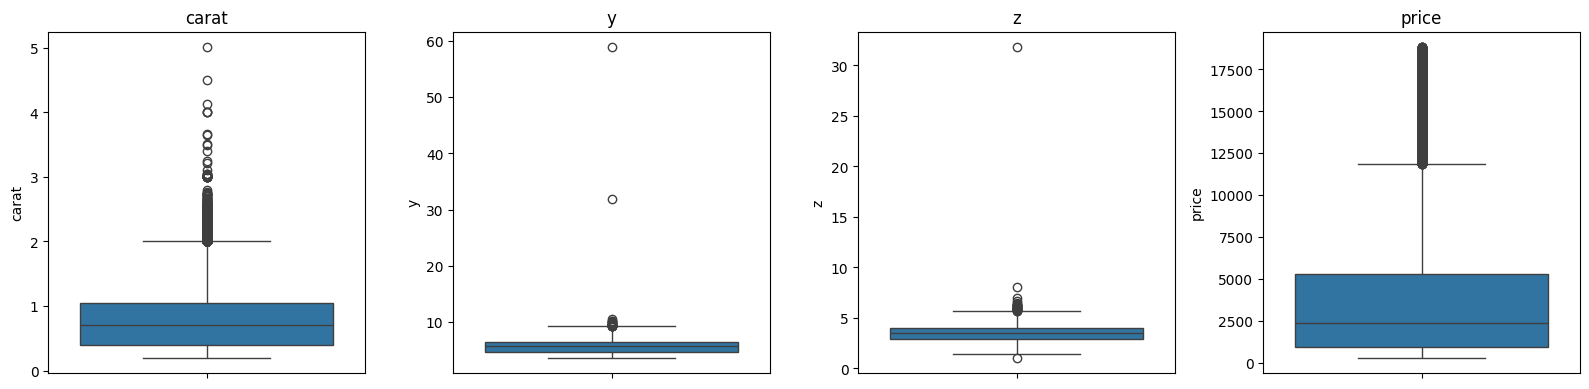

Final shape: (53772, 10)


In [11]:
print("Before:", df.shape)
df = df.drop_duplicates()
print("After:", df.shape)
print((df[["x", "y", "z"]] == 0).sum())
df[["x", "y", "z"]] = df[["x", "y", "z"]].replace(0, np.nan)
df = df.dropna()
print(df.isnull().sum())
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["carat", "y", "z", "price"]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
df = df[(df["y"] < 20) & (df["z"] < 10)]
print("Final shape:", df.shape)
df = df.reset_index(drop=True)

Duplicates were removed because they would count the same diamond twice.
Zero sizes were treated as missing values and dropped, since they were few.
Impossible y and z values were removed as errors.
price outliers were kept because they're real.

## step 4: EDA

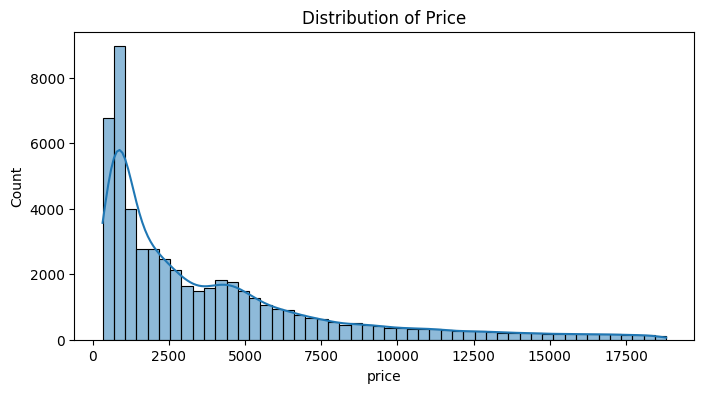

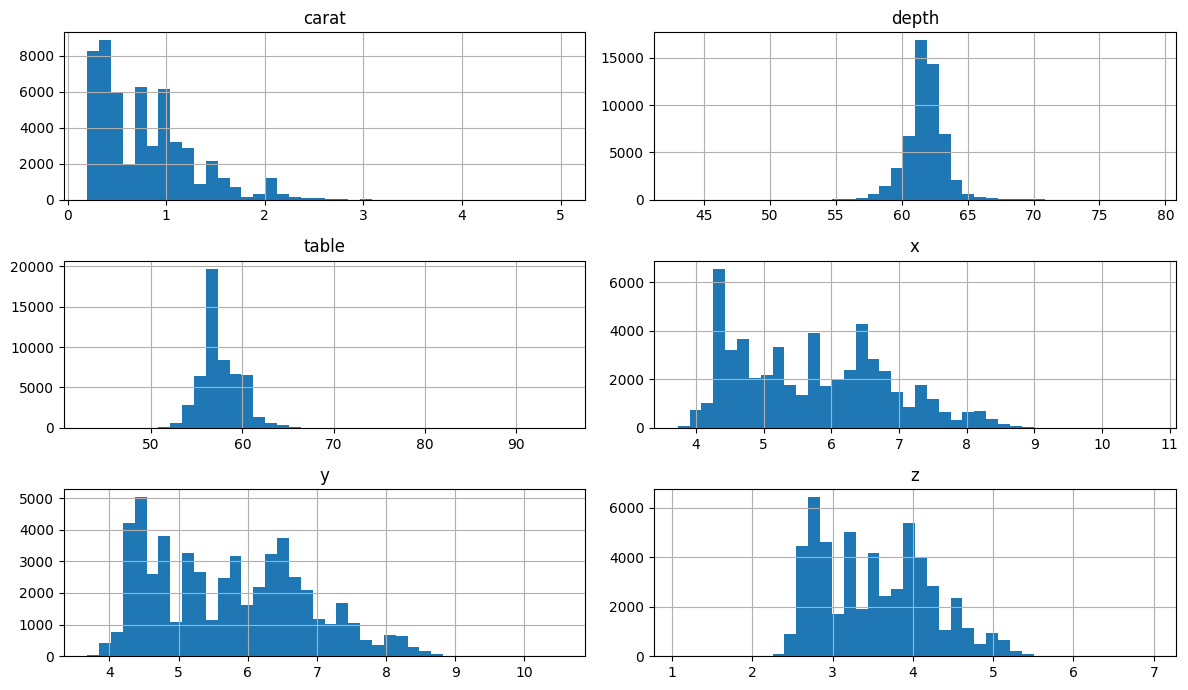

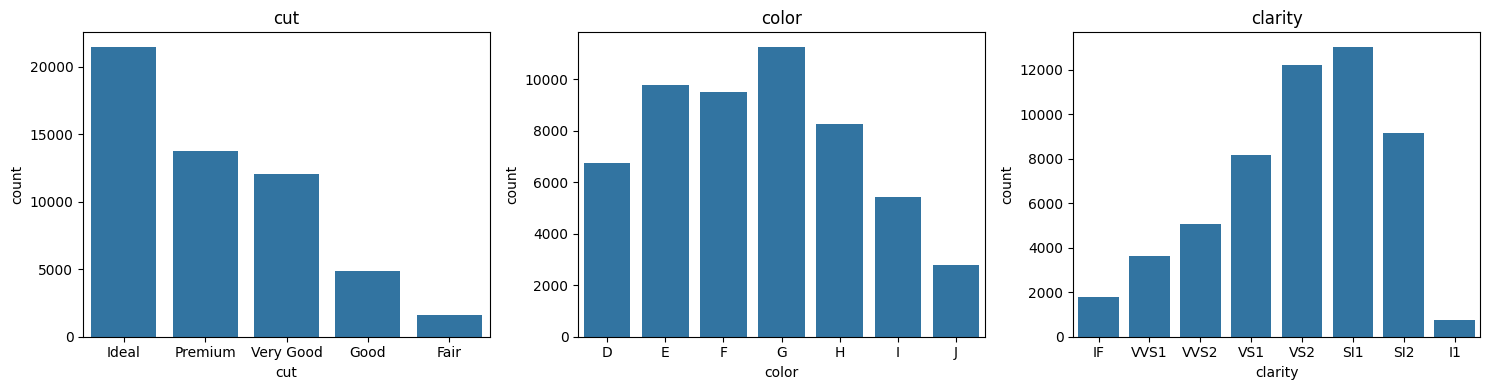

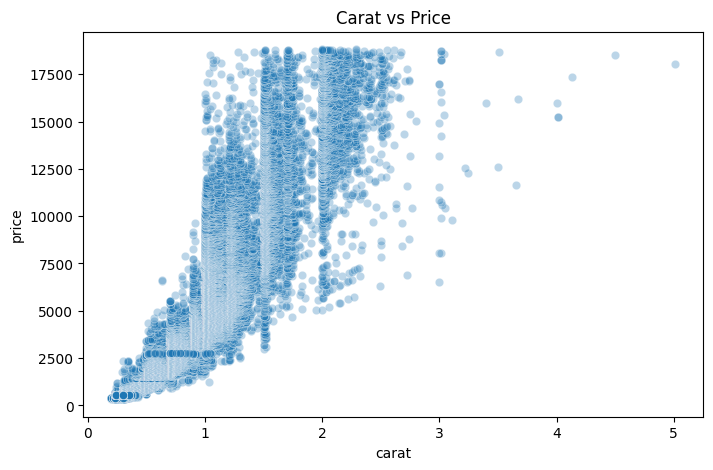

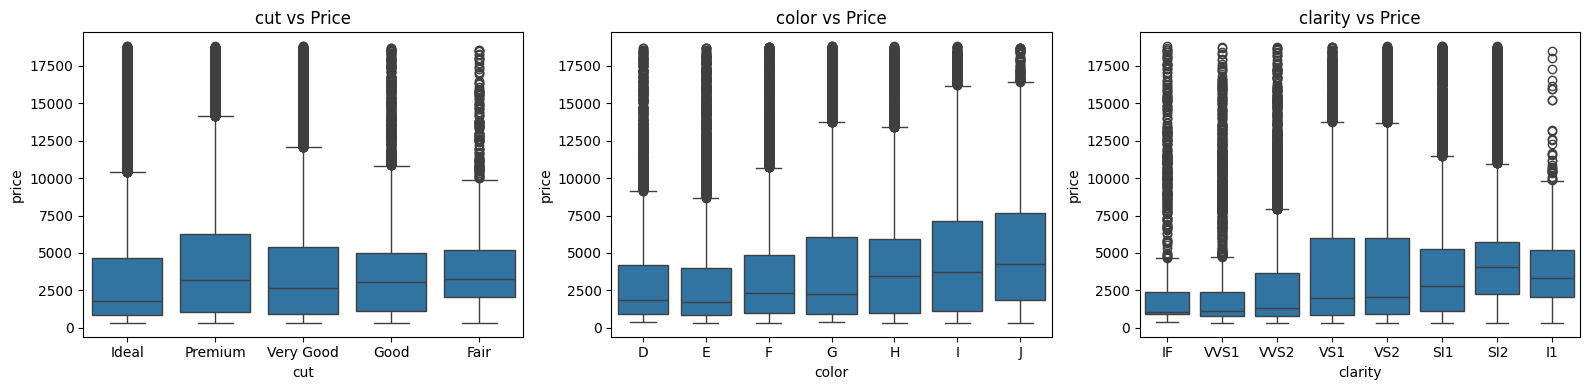

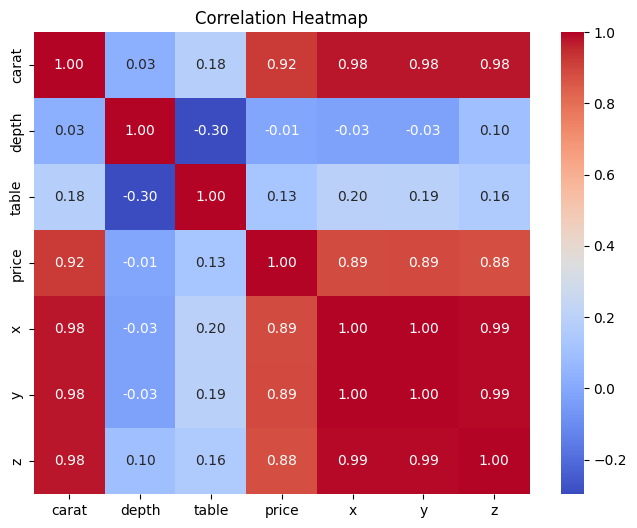

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of Price")
plt.show()
num_cols = ["carat", "depth", "table", "x", "y", "z"]
df[num_cols].hist(bins=40, figsize=(12, 7))
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["cut", "color", "clarity"]):
    sns.countplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
sns.scatterplot(x="carat", y="price", data=df, alpha=0.3)
plt.title("Carat vs Price")
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["cut", "color", "clarity"]):
    sns.boxplot(x=col, y="price", data=df, ax=ax)
    ax.set_title(f"{col} vs Price")
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## step 5 : preprocessing

In [13]:
X = df.drop("price", axis=1)
y = df["price"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ["carat", "depth", "table", "x", "y", "z"]
cat_cols = ["cut", "color", "clarity"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])
X_train_p = preprocessor.fit_transform(X_train)   # learns from train
X_test_p = preprocessor.transform(X_test)         # only applies what it learned

print("Processed train shape:", X_train_p.shape)

Train: (43017, 9) Test: (10755, 9)
Processed train shape: (43017, 23)


## step 6: model training

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
lr = LinearRegression()
lr.fit(X_train_p, y_train)
y_pred_lr = lr.predict(X_test_p)
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_p, y_train)
y_pred_rf = rf.predict(X_test_p)
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train_p, y_train)
y_pred_dt = dt.predict(X_test_p)


## step 7: evaluation

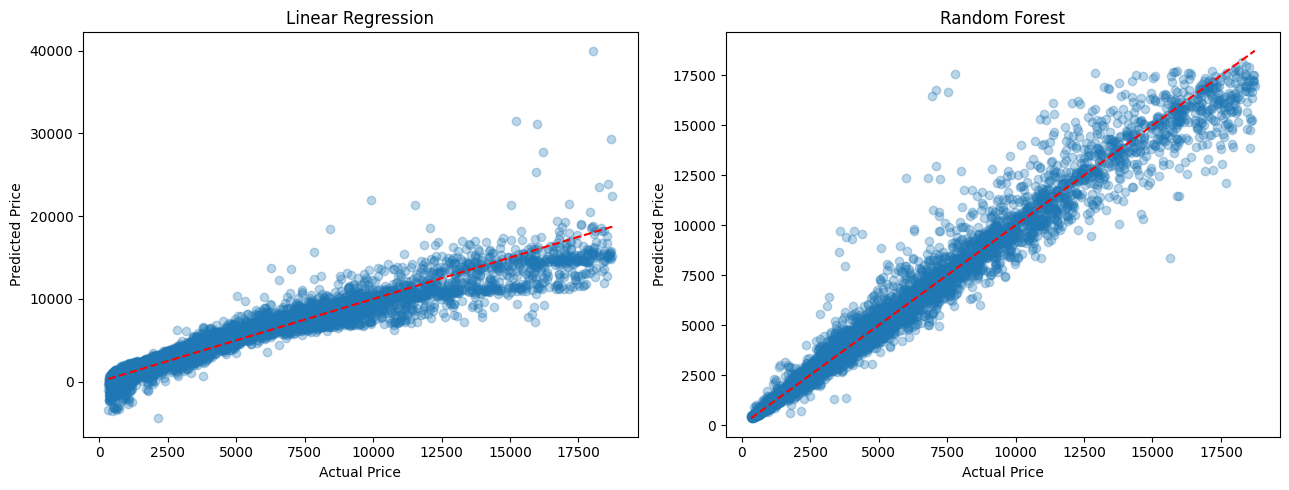

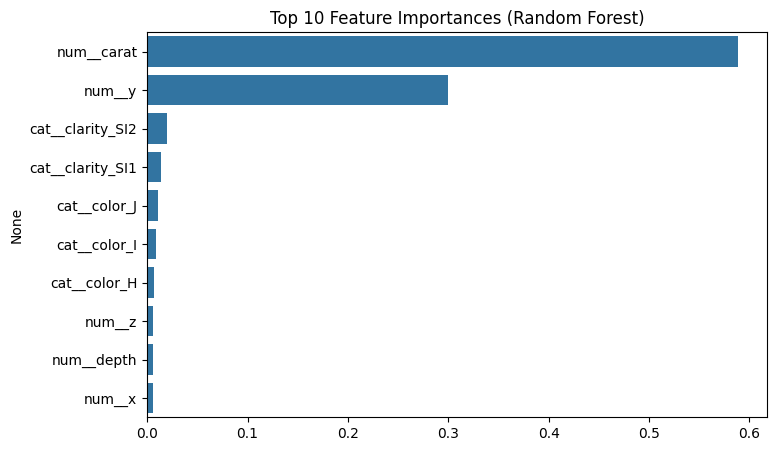

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE": round(rmse, 2), "MAE": round(mae, 2), "R2": round(r2, 4)}
    results = pd.DataFrame([
    evaluate("Linear Regression", y_test, y_pred_lr),
    evaluate("Random Forest", y_test, y_pred_rf),
    evaluate("Decision Tree", y_test, y_pred_dt),   # remove this line if you skipped the optional model
])
resultsfig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred, title in zip(axes, [y_pred_lr, y_pred_rf], ["Linear Regression", "Random Forest"]):
    ax.scatter(y_test, pred, alpha=0.3)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.set_title(title)
plt.tight_layout()
plt.show()
feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

## step 8: save model artifacts

In [20]:
import joblib, os, sklearn

os.makedirs("models", exist_ok=True)
joblib.dump(preprocessor, "models/preprocessor.pkl", compress=3)
joblib.dump(rf, "models/rf_model.pkl", compress=3)

print("scikit-learn version:", sklearn.__version__)
print("Model size (MB):", round(os.path.getsize("models/rf_model.pkl") / 1e6, 1))
rf = RandomForestRegressor(n_estimators=60, max_depth=20, min_samples_leaf=2,
                           random_state=42, n_jobs=-1)
rf.fit(X_train_p, y_train)
print(evaluate("Random Forest (light)", y_test, rf.predict(X_test_p)))
joblib.dump(rf, "models/rf_model.pkl", compress=3)
df.to_csv("diamonds_cleaned.csv", index=False)


scikit-learn version: 1.6.1
Model size (MB): 66.0
{'Model': 'Random Forest (light)', 'RMSE': np.float64(640.52), 'MAE': 297.39, 'R2': 0.9736}
